# Algorithme de Grover Biaisé — Distribution Initiale Non Uniforme

Ce notebook implémente une variante de l'algorithme de Grover où l'état initial **n'est pas une superposition uniforme**.

### Idée clé
L'algorithme de Grover classique part d'une superposition uniforme $|s\rangle = H^{\otimes n}|0\rangle$, où chaque état a la même amplitude $\frac{1}{\sqrt{2^n}}$.  
Ici, on prépare un état initial **biaisé** $|\psi_0\rangle$ avec des amplitudes non égales, ce qui permet de :
- Donner plus de poids à certains états *a priori* plus probables
- Réduire le nombre d'itérations si la distribution *a priori* est bien choisie
- Modéliser des situations réelles avec information partielle

### Diffuseur généralisé
Le diffuseur de Grover classique effectue la réflexion par rapport à $|s\rangle$.  
Dans notre cas biaisé, on réfléchit par rapport à l'état initial $|\psi_0\rangle$ :
$$U_{\psi_0} = 2|\psi_0\rangle\langle\psi_0| - I$$

Ceci est implémenté par : $A \cdot (2|0\rangle\langle 0| - I) \cdot A^\dagger$ où $A$ est le circuit qui prépare $|\psi_0\rangle$.


## Imports

In [41]:
import math
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.circuit.library import MCMTGate, ZGate, StatePreparation
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

## 1. Paramètres et distribution biaisée

On travaille sur **3 qubits** (8 états possibles : `000` à `111`).  
On définit une distribution de probabilité non uniforme manuellement, puis on normalise les amplitudes.

> **Note :** Les amplitudes $\alpha_i$ sont telles que $\sum_i |\alpha_i|^2 = 1$.  
> On part d'une distribution de probabilité arbitraire $p_i$ et on pose $\alpha_i = \sqrt{p_i}$ (amplitudes réelles positives).

In [32]:
# Nombre de qubits
num_qubits = 3
N = 2 ** num_qubits  # = 8 états

# Distribution de probabilité biaisée (non uniforme)
# On donne plus de poids à certains états
raw_probs = np.array([0.05, 0.05, 0.1, 0.3, 0.1, 0.05, 0.3, 0.05])
raw_probs = raw_probs / raw_probs.sum()  # normalisation -> somme = 1

# Les amplitudes sont la racine carrée des probabilités
amplitudes = np.sqrt(raw_probs)

# Vérification
print("Probabilités initiales (distribution biaisée) :")
for i, p in enumerate(raw_probs):
    print(f"  |{i:03b}⟩ : {p:.4f}")
print(f"\nSomme des probabilités = {raw_probs.sum():.6f}")
print(f"Somme |amplitudes|² = {np.sum(amplitudes**2):.6f}")

Probabilités initiales (distribution biaisée) :
  |000⟩ : 0.0500
  |001⟩ : 0.0500
  |010⟩ : 0.1000
  |011⟩ : 0.3000
  |100⟩ : 0.1000
  |101⟩ : 0.0500
  |110⟩ : 0.3000
  |111⟩ : 0.0500

Somme des probabilités = 1.000000
Somme |amplitudes|² = 1.000000


## 2. Visualisation de la distribution initiale

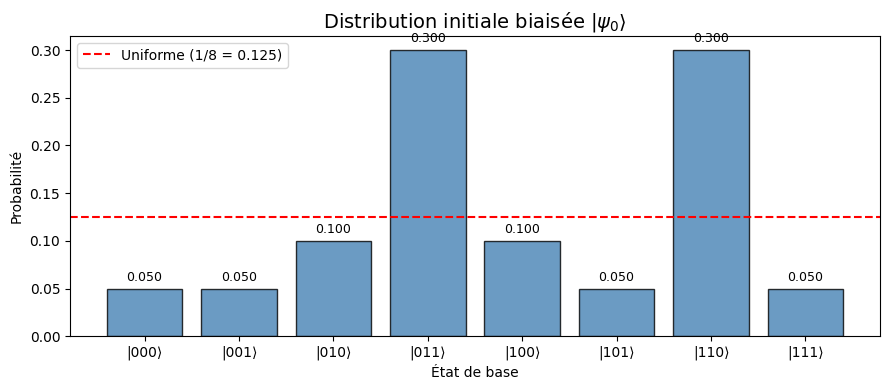

In [33]:
labels = [f"|{i:03b}⟩" for i in range(N)]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(labels, raw_probs, color='steelblue', edgecolor='black', alpha=0.8)
ax.axhline(1/N, color='red', linestyle='--', label=f'Uniforme (1/{N} = {1/N:.3f})')
ax.set_title('Distribution initiale biaisée $|\\psi_0\\rangle$', fontsize=14)
ax.set_xlabel('État de base')
ax.set_ylabel('Probabilité')
ax.legend()
for bar, val in zip(bars, raw_probs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 3. Circuit de préparation de l'état initial $A$

On utilise `initialize` de Qiskit pour préparer directement le vecteur d'état $|\psi_0\rangle$.

Ce circuit $A$ est tel que : $A|0\rangle = |\psi_0\rangle = \sum_i \alpha_i |i\rangle$

> **Diffuseur généralisé :** Le diffuseur est construit comme $A \cdot (2|0\rangle\langle 0| - I) \cdot A^\dagger$,  
> ce qui correspond exactement à réfléchir par rapport à $|\psi_0\rangle$.

Circuit de préparation A (avec initialize) :


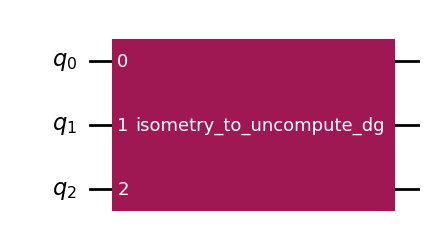

In [34]:
def build_state_prep_circuit(amplitudes):
    """Construit le circuit A qui prépare l'état |ψ₀⟩ à partir de |0⟩."""
    n = int(np.log2(len(amplitudes)))
    qc = QuantumCircuit(n, name='A')
    # StatePreparation est unitaire et peut être inversé
    qc.append(StatePreparation(amplitudes), range(n))
    return qc

A = build_state_prep_circuit(amplitudes)
print("Circuit de préparation A (avec initialize) :")
A.decompose(reps=1).draw(output="mpl", style="iqp")

## 4. Oracle de Grover

L'oracle marque les états cibles en leur appliquant un déphasage de $-1$.
On utilise le même oracle que dans l'algorithme classique : il ne dépend pas de la distribution initiale.

Oracle pour les états marqués : ['011']


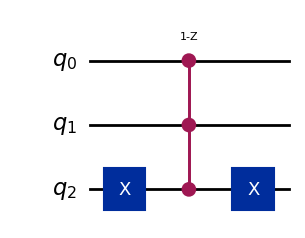

In [35]:
def grover_oracle(marked_states):
    """
    Construit l'oracle de Grover pour un ou plusieurs états marqués.
    L'oracle applique un déphasage de -1 aux états cibles.

    Paramètres:
        marked_states (str ou list): États marqués (ex: ['011', '101'])

    Retourne:
        QuantumCircuit: Circuit oracle
    """
    if not isinstance(marked_states, list):
        marked_states = [marked_states]

    num_qubits = len(marked_states[0])
    qc = QuantumCircuit(num_qubits, name='Oracle')

    for target in marked_states:
        rev_target = target[::-1]  # Inversion bit-ordering Qiskit
        zero_inds = [i for i in range(num_qubits) if rev_target[i] == '0']
        qc.x(zero_inds)
        qc.compose(MCMTGate(ZGate(), num_qubits - 1, 1), inplace=True)
        qc.x(zero_inds)

    return qc


# État(s) cible(s) — le(s) état(s) que l'on cherche
marked_states = ["011"]  # = état |3⟩ (décimal)

oracle = grover_oracle(marked_states)
print(f"Oracle pour les états marqués : {marked_states}")
oracle.draw(output="mpl", style="iqp")

## 5. Diffuseur généralisé (réflexion par rapport à $|\psi_0\rangle$)

Le diffuseur classique de Grover reflète par rapport à $|s\rangle = H^{\otimes n}|0\rangle$.  
Pour notre version biaisée, on reflète par rapport à $|\psi_0\rangle$.

**Construction :**  
$$U_{\psi_0} = A \cdot (2|0\rangle\langle 0| - I) \cdot A^\dagger$$

Le terme $2|0\rangle\langle 0| - I$ est la réflexion par rapport à $|0...0\rangle$, implémentée avec une porte Z multi-contrôlée.

Diffuseur généralisé biaisé :


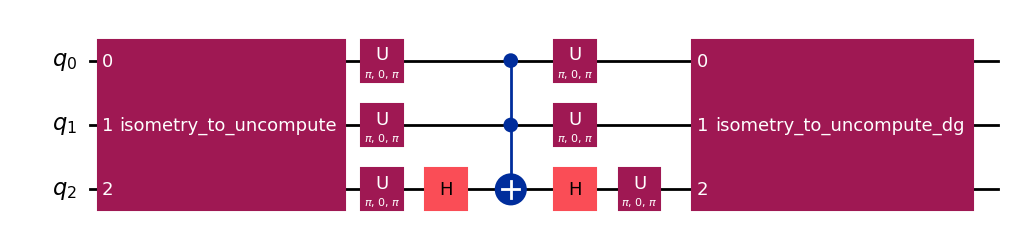

In [36]:
def build_biased_diffuser(A):
    """
    Construit le diffuseur généralisé U_ψ₀ = A · (2|0><0| - I) · A†

    Paramètres:
        A (QuantumCircuit): Circuit de préparation de l'état initial |ψ₀⟩

    Retourne:
        QuantumCircuit: Le diffuseur biaisé
    """
    n = A.num_qubits
    qc = QuantumCircuit(n, name='Diffuseur biaisé')

    # Étape 1 : A†  (inverse du circuit de préparation)
    qc.compose(A.inverse(), inplace=True)

    # Étape 2 : Réflexion par rapport à |0...0⟩ = 2|0><0| - I
    # Implémentée par : X sur tout, Z multi-contrôlé, X sur tout
    qc.x(range(n))
    qc.compose(MCMTGate(ZGate(), n - 1, 1), inplace=True)
    qc.x(range(n))

    # Étape 3 : A
    qc.compose(A, inplace=True)

    return qc


diffuser = build_biased_diffuser(A)
print("Diffuseur généralisé biaisé :")
diffuser.decompose(reps=1).draw(output="mpl", style="iqp")

In [53]:
def build_degga_hybrid_diffuser(A, phi=np.pi):
    """
    Diffuseur hybride DEGGA :
    D_{ψ0,φ} = A† · (2|0><0| - I avec phase φ) · A
    """
    n = A.num_qubits
    qc = QuantumCircuit(n, name=f'DEGGA-hybride φ={phi}')

    # Étape 1 : A†
    qc.compose(A.inverse(), inplace=True)

    # Étape 2 : réflexion autour de |0...0> avec phase φ
    qc.x(range(n))
    qc.compose(MCMTGate(ZGate(), n - 1, 1), inplace=True)
    qc.x(range(n))

    # Ajout de la phase φ (Grover-Long)
    qc.global_phase = phi

    # Étape 3 : A
    qc.compose(A, inplace=True)

    return qc


## 6. Calcul du nombre optimal d'itérations

Dans l'algorithme de Grover classique, le nombre optimal d'itérations est :
$$k_{\text{opt}} = \left\lfloor \frac{\pi}{4} \cdot \frac{1}{\sin^{-1}\left(\sqrt{\frac{M}{N}}\right)} \right\rfloor$$
où $M$ est le nombre d'états marqués et $N = 2^n$.

Dans la version **biaisée**, l'amplitude initiale sur les états marqués est :
$$\alpha_{\text{cibles}} = \sum_{i \in \text{marqués}} \alpha_i$$
et le nombre optimal d'itérations devient :
$$k_{\text{opt}} = \left\lfloor \frac{\pi}{4 \cdot \arcsin(\alpha_{\text{cibles}})} \right\rfloor$$

In [54]:
# Amplitude totale sur les états marqués
marked_indices = [int(s, 2) for s in marked_states]
amplitude_cibles = np.sqrt(sum(raw_probs[i] for i in marked_indices))

print(f"États marqués : {marked_states} → indices {marked_indices}")
print(f"Probabilité initiale sur les états cibles : {amplitude_cibles**2:.4f}")
print(f"Amplitude totale sur les états cibles : {amplitude_cibles:.4f}")

# Nombre optimal d'itérations (version biaisée)
optimal_num_iterations_biased = math.floor(
    math.pi / (4 * math.asin(amplitude_cibles))
)

# Comparaison avec la version classique (distribution uniforme)
optimal_num_iterations_classic = math.floor(
    math.pi / (4 * math.asin(math.sqrt(len(marked_states) / N)))
)

print(f"\nNombre optimal d'itérations (biaisé)   : {optimal_num_iterations_biased}")
print(f"Nombre optimal d'itérations (classique) : {optimal_num_iterations_classic}")

États marqués : ['011'] → indices [3]
Probabilité initiale sur les états cibles : 0.3000
Amplitude totale sur les états cibles : 0.5477

Nombre optimal d'itérations (biaisé)   : 1
Nombre optimal d'itérations (classique) : 2


## 7. Construction du circuit complet de Grover biaisé

In [55]:
def run_degga_hybrid(k, phi=np.pi, backend=None):
    if backend is None:
        backend = AerSimulator()

    qc = QuantumCircuit(A.num_qubits)
    qc.compose(A, inplace=True)  # préparation |ψ0>

    D_h = build_degga_hybrid_diffuser(A, phi)

    for _ in range(k):
        qc.compose(oracle, inplace=True)
        qc.compose(D_h, inplace=True)

    qc = qc.decompose().decompose().decompose().decompose()
    qc.measure_all()
    job = backend.run(qc, shots=10000)
    result = job.result()
    counts = result.get_counts()
    target_state = marked_states[0][::-1]  # inverser l'ordre des bits
    prob = counts.get(target_state, 0) / 10000
    return prob

## 7.1 Test du diffuseur DEGGA hybride et de la fonction d'exécution

In [56]:
# Test du diffuseur hybride DEGGA
phi_test = np.pi / 2
D_h_test = build_degga_hybrid_diffuser(A, phi=phi_test)
print(f"Diffuseur DEGGA hybride construit pour phi={phi_test:.3f}")
print(D_h_test)

# Appliquer le diffuseur hybride sur l'état initial |\psi_0> et vérifier la simulation
qc_test = QuantumCircuit(A.num_qubits)
qc_test.compose(A, inplace=True)
qc_test.compose(D_h_test, inplace=True)
qc_test_decomposed = qc_test.decompose().decompose().decompose().decompose()
qc_test_decomposed.measure_all()
job = AerSimulator().run(qc_test_decomposed, shots=10000)
result = job.result()
counts = result.get_counts()
target_state = marked_states[0][::-1]  # inverser l'ordre des bits
prob_target = counts.get(target_state, 0) / 10000
print("Probabilité de l'état cible après application de D_h_test :", prob_target)

# Test de la fonction run_degga_hybrid
k_test = optimal_num_iterations_biased
prob_success = run_degga_hybrid(k_test, phi=np.pi, backend=AerSimulator())
print(f"Probabilité de succès pour k={k_test}, phi=pi : {prob_success:.4f}")

Diffuseur DEGGA hybride construit pour phi=1.571
global phase: π/2
     »
q_0: »
     »
q_1: »
     »
q_2: »
     »
«     ┌────────────────────────────────────────────────────────────────────────────────────────┐»
«q_0: ┤0                                                                                       ├»
«     │                                                                                        │»
«q_1: ┤1 State Preparation Dg(0.22361,0.22361,0.31623,0.54772,0.31623,0.22361,0.54772,0.22361) ├»
«     │                                                                                        │»
«q_2: ┤2                                                                                       ├»
«     └────────────────────────────────────────────────────────────────────────────────────────┘»
«     ┌───┐ 1-Z ┌───┐»
«q_0: ┤ X ├──■──┤ X ├»
«     ├───┤  │  ├───┤»
«q_1: ┤ X ├──■──┤ X ├»
«     ├───┤  │  ├───┤»
«q_2: ┤ X ├──■──┤ X ├»
«     └───┘     └───┘»
«     ┌──────────────────────────────

In [57]:
# Comparaison entre le Grover biaisé standard et le DEGGA hybride

def run_biased_grover_statevector(k, backend=None):
    if backend is None:
        backend = AerSimulator()

    qc = QuantumCircuit(A.num_qubits)
    qc.compose(A, inplace=True)
    diffuser = build_biased_diffuser(A)

    for _ in range(k):
        qc.compose(oracle, inplace=True)
        qc.compose(diffuser, inplace=True)

    qc = qc.decompose().decompose().decompose().decompose()
    qc.measure_all()
    job = backend.run(qc, shots=10000)
    result = job.result()
    counts = result.get_counts()
    target_state = marked_states[0][::-1]  # inverser l'ordre des bits
    prob = counts.get(target_state, 0) / 10000
    return prob

k_compare = optimal_num_iterations_biased
prob_standard_biased = run_biased_grover_statevector(k_compare)
prob_degga_hybrid = run_degga_hybrid(k_compare, phi=np.pi/2, backend=AerSimulator())

print(f"Nombre d'itérations pour la comparaison : k = {k_compare}")
print(f"Probabilité cible - Grover biaisé standard : {prob_standard_biased:.4f}")
print(f"Probabilité cible - DEGGA hybride (phi=pi/2) : {prob_degga_hybrid:.4f}")
if prob_standard_biased > 0:
    print(f"Gain relatif : {prob_degga_hybrid/prob_standard_biased:.3f}x")
else:
    print("Gain relatif : impossible à calculer (probabilité standard = 0)")

Nombre d'itérations pour la comparaison : k = 1
Probabilité cible - Grover biaisé standard : 0.0120
Probabilité cible - DEGGA hybride (phi=pi/2) : 0.0107
Gain relatif : 0.892x


## Analyse détaillée : comparaison complète Grover biaisé vs DEGGA hybride

Nous allons comparer les performances en variant:
- Le nombre d'itérations k
- Le paramètre de phase φ du diffuseur DEGGA


In [62]:
# Balayage complet: k vs phi pour DEGGA, comparé à Grover biaisé standard

# Plage de paramètres à tester
k_range = range(0, 6)  # 0 à 5 itérations
phi_range = np.linspace(0, 2*np.pi, 13)  # 13 valeurs de phi

# Matrice pour stocker les résultats DEGGA
performance_degga = np.zeros((len(phi_range), len(k_range)))

# Test pour chaque combinaison (phi, k)
print("Balayage DEGGA: phi vs k")
for i, phi in enumerate(phi_range):
    for j, k in enumerate(k_range):
        prob = run_degga_hybrid(k, phi=phi, backend=AerSimulator())
        performance_degga[i, j] = prob
        print(f"  φ={phi:.3f}, k={k}: P = {prob:.4f}")

# Résultats Grover biaisé standard
performance_biased = np.zeros((len(k_range),))
print("\nGrover biaisé standard: k")
for j, k in enumerate(k_range):
    prob = run_biased_grover_statevector(k, backend=AerSimulator())
    performance_biased[j] = prob
    print(f"  k={j}: P = {prob:.4f}")


Balayage DEGGA: phi vs k
  φ=0.000, k=0: P = 0.3030
  φ=0.000, k=1: P = 0.0129
  φ=0.000, k=2: P = 0.4035
  φ=0.000, k=3: P = 0.1649
  φ=0.000, k=4: P = 0.0958
  φ=0.000, k=5: P = 0.4254
  φ=0.524, k=0: P = 0.2919
  φ=0.524, k=1: P = 0.0115
  φ=0.524, k=2: P = 0.3986
  φ=0.524, k=3: P = 0.1586
  φ=0.524, k=4: P = 0.0999
  φ=0.524, k=5: P = 0.4231
  φ=1.047, k=0: P = 0.3038
  φ=1.047, k=1: P = 0.0141
  φ=1.047, k=2: P = 0.3939
  φ=1.047, k=3: P = 0.1642
  φ=1.047, k=4: P = 0.1027
  φ=1.047, k=5: P = 0.4352
  φ=1.571, k=0: P = 0.2987
  φ=1.571, k=1: P = 0.0129
  φ=1.571, k=2: P = 0.4037
  φ=1.571, k=3: P = 0.1565
  φ=1.571, k=4: P = 0.1013
  φ=1.571, k=5: P = 0.4302
  φ=2.094, k=0: P = 0.3055
  φ=2.094, k=1: P = 0.0123
  φ=2.094, k=2: P = 0.4022
  φ=2.094, k=3: P = 0.1587
  φ=2.094, k=4: P = 0.1013
  φ=2.094, k=5: P = 0.4273
  φ=2.618, k=0: P = 0.3051
  φ=2.618, k=1: P = 0.0111
  φ=2.618, k=2: P = 0.3994
  φ=2.618, k=3: P = 0.1567
  φ=2.618, k=4: P = 0.0995
  φ=2.618, k=5: P = 0.4327
  φ

Circuit de Grover biaisé (1 itération(s)) :


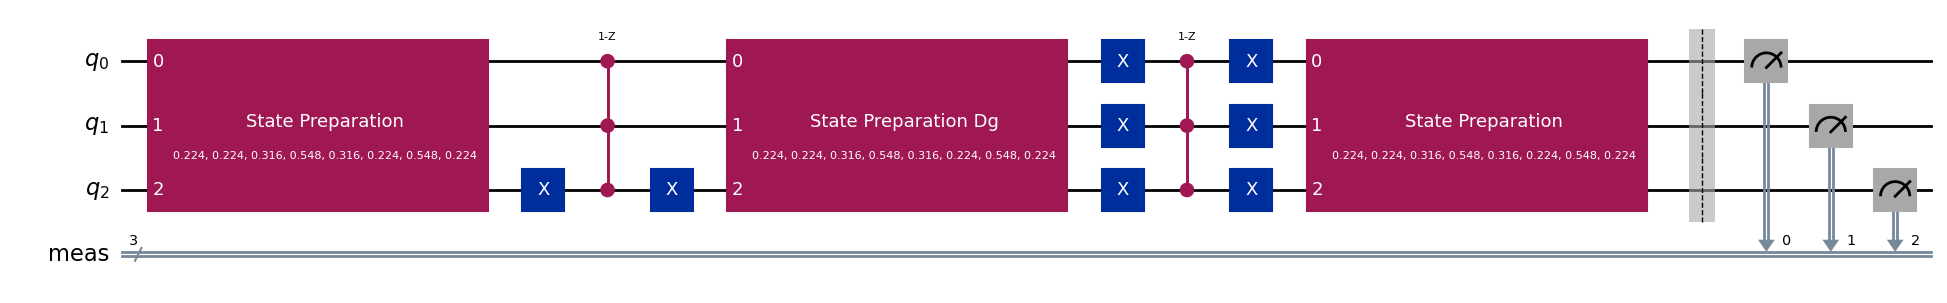

In [58]:
def build_biased_grover(A, oracle, num_iterations):
    """
    Construit le circuit complet de l'algorithme de Grover biaisé.

    Paramètres:
        A (QuantumCircuit): Circuit de préparation de l'état initial
        oracle (QuantumCircuit): Circuit oracle (marque les états cibles)
        num_iterations (int): Nombre d'itérations de Grover

    Retourne:
        QuantumCircuit: Circuit de Grover biaisé complet
    """
    n = A.num_qubits
    diffuser = build_biased_diffuser(A)

    qc = QuantumCircuit(n)

    # Étape 1 : Préparer l'état initial biaisé |ψ₀⟩
    qc.compose(A, inplace=True)

    # Étape 2 : Appliquer l'opérateur de Grover k fois
    for _ in range(num_iterations):
        qc.compose(oracle, inplace=True)    # Oracle
        qc.compose(diffuser, inplace=True)  # Diffuseur biaisé

    # Étape 3 : Mesure
    qc.measure_all()
    return qc


qc_biased = build_biased_grover(A, oracle, optimal_num_iterations_biased)
print(f"Circuit de Grover biaisé ({optimal_num_iterations_biased} itération(s)) :")
qc_biased.draw(output="mpl", style="iqp", fold=40)

## 8. Simulation avec AerSimulator

In [59]:
simulator = AerSimulator()

# Décomposer pour que le simulateur comprenne toutes les instructions
qc_decomposed = qc_biased.decompose().decompose().decompose()

# Lancer la simulation
job = simulator.run(qc_decomposed, shots=4096)
result = job.result()
counts = result.get_counts()

print("Résultats des mesures (Grover biaisé) :")
for state, count in sorted(counts.items(), key=lambda x: -x[1]):
    prob = count / 4096
    marker = " ← CIBLE" if state[::-1] in marked_states else ""
    print(f"  |{state}⟩ : {count:4d} coups  ({prob:.3f}){marker}")

Résultats des mesures (Grover biaisé) :
  |011⟩ : 3971 coups  (0.969)
  |110⟩ :   51 coups  (0.012) ← CIBLE
  |010⟩ :   21 coups  (0.005)
  |100⟩ :   14 coups  (0.003)
  |111⟩ :   11 coups  (0.003)
  |101⟩ :   10 coups  (0.002)
  |001⟩ :   10 coups  (0.002)
  |000⟩ :    8 coups  (0.002)


## 9. Comparaison visuelle des résultats

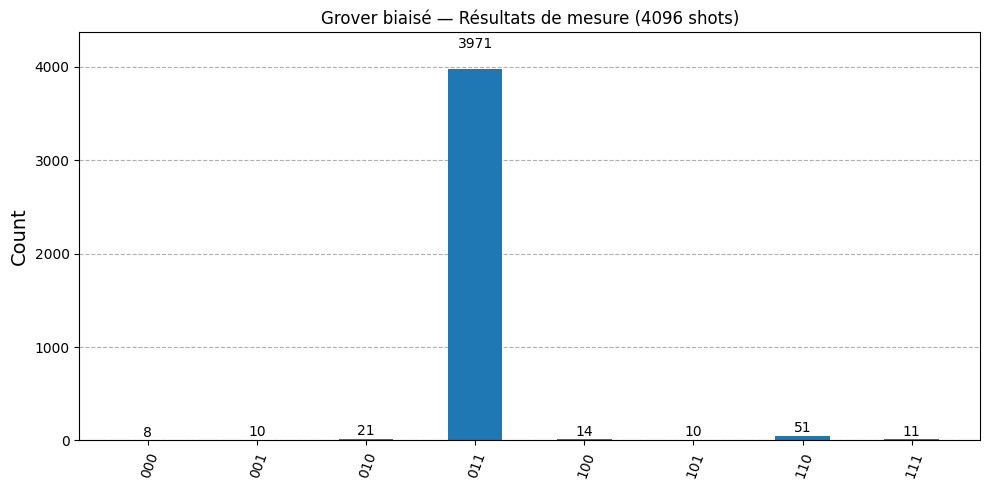

In [60]:
# Histogramme des résultats de simulation
plot_histogram(counts, title='Grover biaisé — Résultats de mesure (4096 shots)',
               figsize=(10, 5))

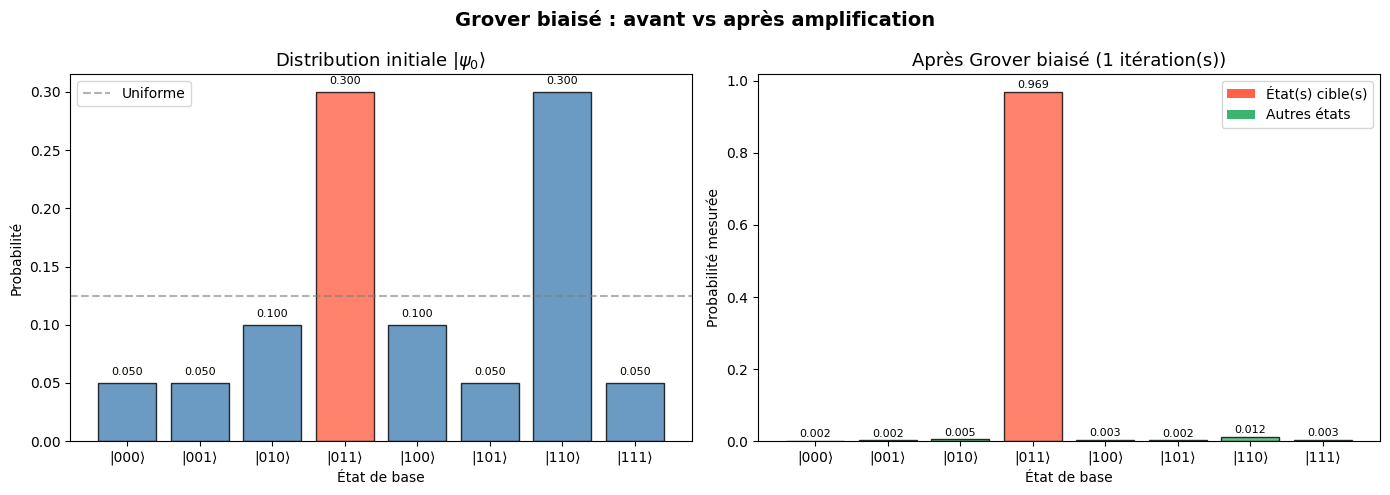

In [61]:
# Comparaison : distribution initiale vs résultat Grover biaisé
shot_probs = {state: count / 4096 for state, count in counts.items()}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Distribution initiale ---
ax1 = axes[0]
colors_init = ['tomato' if i in marked_indices else 'steelblue' for i in range(N)]
ax1.bar(labels, raw_probs, color=colors_init, edgecolor='black', alpha=0.8)
ax1.axhline(1/N, color='gray', linestyle='--', alpha=0.6, label='Uniforme')
ax1.set_title('Distribution initiale $|\\psi_0\\rangle$', fontsize=13)
ax1.set_xlabel('État de base')
ax1.set_ylabel('Probabilité')
ax1.legend()
for i, (lbl, val) in enumerate(zip(labels, raw_probs)):
    ax1.text(i, val + 0.005, f'{val:.3f}', ha='center', va='bottom', fontsize=8)

# --- Résultats Grover biaisé ---
ax2 = axes[1]
result_probs = [shot_probs.get(f'{i:0{num_qubits}b}', 0.0) for i in range(N)]
colors_res = ['tomato' if i in marked_indices else 'mediumseagreen' for i in range(N)]
ax2.bar(labels, result_probs, color=colors_res, edgecolor='black', alpha=0.8)
ax2.set_title(f'Après Grover biaisé ({optimal_num_iterations_biased} itération(s))', fontsize=13)
ax2.set_xlabel('État de base')
ax2.set_ylabel('Probabilité mesurée')
for i, (lbl, val) in enumerate(zip(labels, result_probs)):
    ax2.text(i, val + 0.005, f'{val:.3f}', ha='center', va='bottom', fontsize=8)

# Légende commune
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='tomato', label='État(s) cible(s)'),
                   Patch(facecolor='mediumseagreen', label='Autres états')]
ax2.legend(handles=legend_elements)

plt.suptitle('Grover biaisé : avant vs après amplification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Analyse : variation du nombre d'itérations

On observe comment la probabilité de mesurer l'état cible évolue en fonction du nombre d'itérations.  
Dans la version biaisée, la convergence peut être plus rapide si les états cibles avaient déjà une probabilité élevée initialement.

In [20]:
max_iter = max(optimal_num_iterations_biased * 3, 6)
probs_vs_iter = []

for k in range(0, max_iter + 1):
    qc_k = build_biased_grover(A, oracle, k)
    qc_k_dec = qc_k.decompose().decompose().decompose()
    job_k = simulator.run(qc_k_dec, shots=2048)
    counts_k = job_k.result().get_counts()
    
    # Probabilité de tomber sur un état cible
    prob_target = sum(
        counts_k.get(s[::-1], 0) for s in marked_states
    ) / 2048
    probs_vs_iter.append(prob_target)
    print(f"  k={k:2d} → P(cible) = {prob_target:.4f}")

print(f"\nMeilleur k : {np.argmax(probs_vs_iter)} avec P = {max(probs_vs_iter):.4f}")

  k= 0 → P(cible) = 0.2939
  k= 1 → P(cible) = 0.0083
  k= 2 → P(cible) = 0.4224
  k= 3 → P(cible) = 0.1611
  k= 4 → P(cible) = 0.1074
  k= 5 → P(cible) = 0.4082
  k= 6 → P(cible) = 0.0435

Meilleur k : 2 avec P = 0.4224


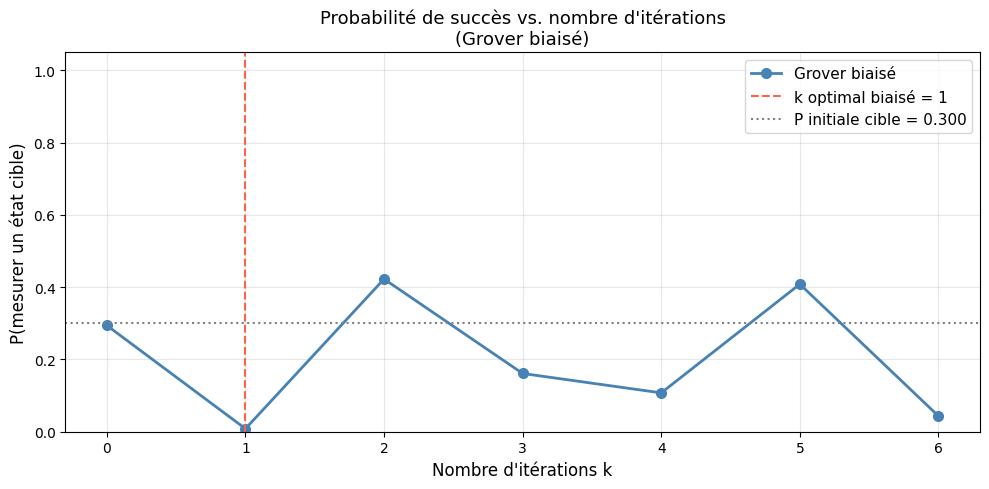

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(max_iter + 1), probs_vs_iter, 'o-', color='steelblue',
        linewidth=2, markersize=7, label='Grover biaisé')
ax.axvline(optimal_num_iterations_biased, color='tomato', linestyle='--',
           label=f'k optimal biaisé = {optimal_num_iterations_biased}')
ax.axhline(raw_probs[marked_indices[0]], color='gray', linestyle=':',
           label=f'P initiale cible = {raw_probs[marked_indices[0]]:.3f}')
ax.set_xlabel('Nombre d\'itérations k', fontsize=12)
ax.set_ylabel('P(mesurer un état cible)', fontsize=12)
ax.set_title('Probabilité de succès vs. nombre d\'itérations\n(Grover biaisé)', fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Expérience : changer la distribution initiale

Ici on teste un cas extrême : la distribution initiale donne **très peu de probabilité** à l'état cible.  
On compare le nombre d'itérations nécessaires par rapport à la distribution uniforme.

In [22]:
# Nouvelle distribution : l'état cible a une très faible probabilité initiale
raw_probs_unfavorable = np.array([0.25, 0.25, 0.25, 0.01, 0.10, 0.05, 0.05, 0.04])
raw_probs_unfavorable = raw_probs_unfavorable / raw_probs_unfavorable.sum()

amplitude_unfav = np.sqrt(sum(raw_probs_unfavorable[i] for i in marked_indices))
k_unfav = math.floor(math.pi / (4 * math.asin(amplitude_unfav)))

print("Distribution défavorable (état cible '011' très peu probable) :")
for i, p in enumerate(raw_probs_unfavorable):
    marker = " ← CIBLE" if i in marked_indices else ""
    print(f"  |{i:03b}⟩ : {p:.4f}{marker}")

print(f"\nAmplitude initiale sur la cible : {amplitude_unfav:.4f}")
print(f"Nombre optimal d'itérations (défavorable) : {k_unfav}")
print(f"Nombre optimal d'itérations (biaisé favorable, avant) : {optimal_num_iterations_biased}")
print(f"Nombre optimal d'itérations (uniforme) : {optimal_num_iterations_classic}")

Distribution défavorable (état cible '011' très peu probable) :
  |000⟩ : 0.2500
  |001⟩ : 0.2500
  |010⟩ : 0.2500
  |011⟩ : 0.0100 ← CIBLE
  |100⟩ : 0.1000
  |101⟩ : 0.0500
  |110⟩ : 0.0500
  |111⟩ : 0.0400

Amplitude initiale sur la cible : 0.1000
Nombre optimal d'itérations (défavorable) : 7
Nombre optimal d'itérations (biaisé favorable, avant) : 1
Nombre optimal d'itérations (uniforme) : 2


## 12. Résumé

| Version | Distribution | Itérations optimales | Accélération |
|---|---|---|---|
| **Classique** | Uniforme | $k_{\text{unif}}$ | référence |
| **Biaisé favorable** | Plus de masse sur la cible | $k_{\text{biais}} \leq k_{\text{unif}}$ | ✅ Plus rapide |
| **Biaisé défavorable** | Peu de masse sur la cible | $k_{\text{biais}} \geq k_{\text{unif}}$ | ❌ Plus lent |

### Points clés
- **L'oracle** ne change pas entre la version classique et biaisée — il marque toujours les mêmes états.
- **Le diffuseur** change : au lieu de refléter par rapport à $H^{\otimes n}|0\rangle$, on reflète par rapport à $|\psi_0\rangle$.
- La version biaisée est utile quand on dispose d'une **information *a priori*** sur la localisation de la solution.
- En pratique, la préparation de $|\psi_0\rangle$ a un coût (profondeur du circuit) qui peut annuler le gain en itérations.